# DAT 402 Project 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
random_seed = 42
df = pd.read_csv("retail_trader_master.csv")
df=df.sample(n=1000, random_state=random_seed)

### Retail Trader Survival — Who Blows Up, Survives
For this project we decided to go with the dataset "Retail Trader Survival — Who Blows Up, Survives" (https://www.kaggle.com/datasets/sergionefedov/retail-trader-survival-who-blows-up-survives?select=retail_trader_master.csv) from Kaggle. Using the dataset, our goal was to predict whether a trader will "survive" or "blow up" their account using binary classification based on things like trades per month, percentage of account risked on each position, and behavioral traits. 

This dataset consists of 50,000 observations, but I narrowed it down to 1,000 observations to make the analysis more manageable and trends easier to see. The features are separated into two categories: behavior and circumstance. This dataset is important because retail trading has a high failure rate. A model that identifies behavioral or account patterns associated with trading blowups could help traders better understand the risks and serve as an early warning system.


The dataset contains 21 features:

Behavioral
- risk_per_trade_pct (%)
- avg_leverage
- trades_per_month
- uses_stop_loss (binary, 1 if consistently use stop losses)
- avg_win_hold_days
- avg_loss_hold_days
- diversification (0-10)
- journals_trades (0-2)
- revenge_trading (0-10)
- overconfidence (0-10)
- follows_plan (0-10)
- chases_volatility (0-10)
- position_sizing_discipline (0-10)

Circumstance
- trader_id (string)
- age
- prior_experience_years (years)
- starting_capital (USD)
- account_age_months (months)
- instrument (stock/etf/forex/crypto/options/futures)
- market_regime (bull/choppy/bear)
- broker_cost_bps

And 3 targets:
- net_return_pct (%)
- profitable (binary, 1 if net return >0)
- blew_up (binary, 1 if lost >=70% of account)



In [2]:
#display part of the data, check for nulls and duplicates
display(df.head())
display(df.isnull().sum())
display(df.duplicated().sum())

,trader_id,age,prior_experience_years,starting_capital,account_age_months,instrument,market_regime,broker_cost_bps,risk_per_trade_pct,avg_leverage,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
33553,TRD033553,50,0.3,12340.0,14,stocks,choppy,23.7,2.22,1.0,...,5.7,2,9.1,5.4,4.1,7.8,7.0,-40.0,0,1
9427,TRD009427,35,4.5,6980.0,13,stocks,bear,12.4,2.83,1.8,...,3.9,1,4.7,4.2,3.8,9.5,8.5,-3.8,0,0
199,TRD000199,39,1.0,4440.0,12,forex,bull,6.0,0.36,6.1,...,3.3,1,6.0,5.7,5.2,8.0,8.9,-40.0,0,1
12447,TRD012447,52,2.9,6400.0,24,futures,choppy,15.8,2.01,10.8,...,3.0,0,8.3,3.4,0.0,7.8,5.8,1.8,1,0
39489,TRD039489,40,2.9,26250.0,5,crypto,bull,14.4,0.81,3.0,...,2.3,2,8.9,4.3,5.3,7.0,8.0,17.1,1,0


trader_id                     0
age                           0
prior_experience_years        0
starting_capital              0
account_age_months            0
instrument                    0
market_regime                 0
broker_cost_bps               0
risk_per_trade_pct            0
avg_leverage                  0
trades_per_month              0
uses_stop_loss                0
avg_win_hold_days             0
avg_loss_hold_days            0
diversification               0
journals_trades               0
revenge_trading               0
overconfidence                0
follows_plan                  0
chases_volatility             0
position_sizing_discipline    0
net_return_pct                0
profitable                    0
blew_up                       0
dtype: int64

np.int64(0)

### Clean up

Note: The data does not have any null, missing, and duplicate values, so we do not need to clean up the values.

In [3]:
display(df.describe())
display(df.info())

,age,prior_experience_years,starting_capital,account_age_months,broker_cost_bps,risk_per_trade_pct,avg_leverage,trades_per_month,uses_stop_loss,avg_win_hold_days,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.717000,2.243400,9292.600000,16.32300,11.76640,2.26821,6.191400,32.287000,0.492000,6.616200,...,4.073700,0.603000,5.063700,4.929000,5.365600,6.768900,7.413800,-21.354900,0.181000,0.448000
std,9.894484,1.920355,11651.220192,13.08885,8.09404,1.64651,5.791691,23.686699,0.500186,5.312489,...,2.023772,0.745618,2.264416,2.235504,2.262042,2.146894,2.117525,19.586417,0.385211,0.497537
min,18.000000,0.000000,200.000000,1.00000,0.50000,0.10000,1.000000,1.000000,0.000000,0.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,-55.800000,0.000000,0.000000
25%,27.000000,0.900000,2700.000000,7.00000,5.70000,1.11750,1.600000,14.750000,0.000000,2.775000,...,2.675000,0.000000,3.575000,3.400000,3.900000,5.200000,5.900000,-40.000000,0.000000,0.000000
50%,35.000000,1.700000,5475.000000,13.00000,10.10000,1.88000,4.200000,27.000000,0.000000,5.450000,...,4.100000,0.000000,4.900000,5.000000,5.400000,6.800000,7.600000,-24.200000,0.000000,0.000000
75%,41.250000,3.025000,11092.500000,23.00000,15.70000,2.95500,9.500000,44.000000,1.000000,9.025000,...,5.425000,1.000000,6.600000,6.500000,6.900000,8.400000,9.300000,-4.600000,0.000000,1.000000
max,70.000000,13.400000,130530.000000,95.00000,48.10000,12.05000,44.400000,145.000000,1.000000,45.100000,...,10.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,34.600000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 33553 to 13664
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trader_id                   1000 non-null   object 
 1   age                         1000 non-null   int64  
 2   prior_experience_years      1000 non-null   float64
 3   starting_capital            1000 non-null   float64
 4   account_age_months          1000 non-null   int64  
 5   instrument                  1000 non-null   object 
 6   market_regime               1000 non-null   object 
 7   broker_cost_bps             1000 non-null   float64
 8   risk_per_trade_pct          1000 non-null   float64
 9   avg_leverage                1000 non-null   float64
 10  trades_per_month            1000 non-null   int64  
 11  uses_stop_loss              1000 non-null   int64  
 12  avg_win_hold_days           1000 non-null   float64
 13  avg_loss_hold_days          1000 

None

### Exploratory Data Analysis

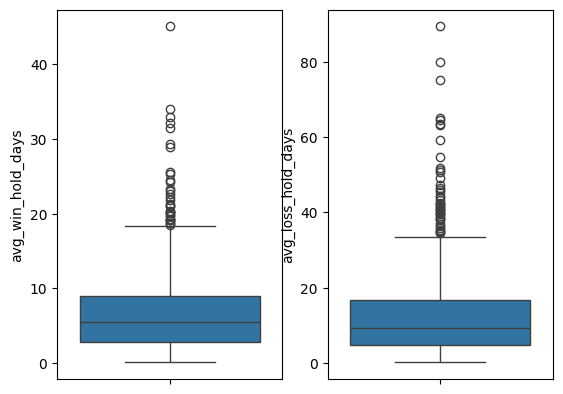

In [4]:
#boxplots of avg_win_hold_days and avg_loss_hold_days
plt.subplot(1, 2, 1)
win=sns.boxplot(data=df, y='avg_win_hold_days')
plt.subplot(1, 2, 2)
loss=sns.boxplot(data=df, y='avg_loss_hold_days')

Observation: Both boxplots have similar distribution for average days of holding trades whether win or loss. The median for average loss hold is lower than win, and has more outliers. 

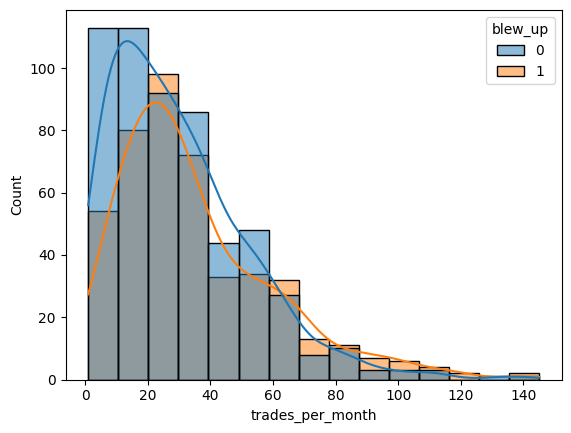

In [5]:
#histogram of trades_per_month differentiating between traders who blew up and those who didn't
sns.histplot(data=df, hue='blew_up', x='trades_per_month', bins=15, kde=True)
plt.show()

Observation: Traders who did not blow up mostly trade 0-20 times per month, whereas traders who did blow up (lost over 70 percent of their account) trade around 10-30 times per month. 

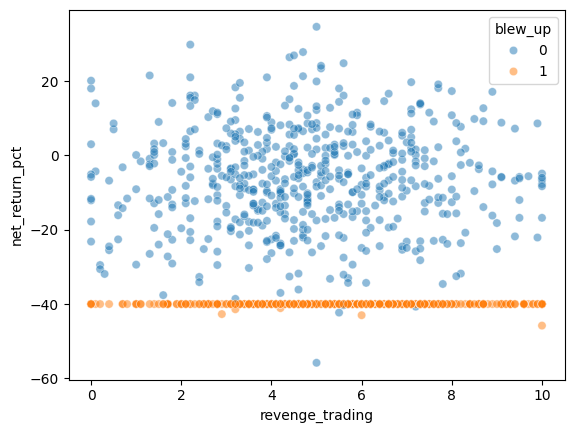

In [6]:
#scatterplot looking at revenge trading and net return percent (does revenge trading lead to lower returns?)
sns.scatterplot(data=df, x='revenge_trading', y='net_return_pct', alpha=0.5, hue='blew_up')
plt.show()

Observation: All accounts that have blown up are set to a default value for revenge trading. Accounts that do not blow up do not seem to have a correlation with frequency of revenge trading, but most traders are in the middle with how much they revenge trade. 

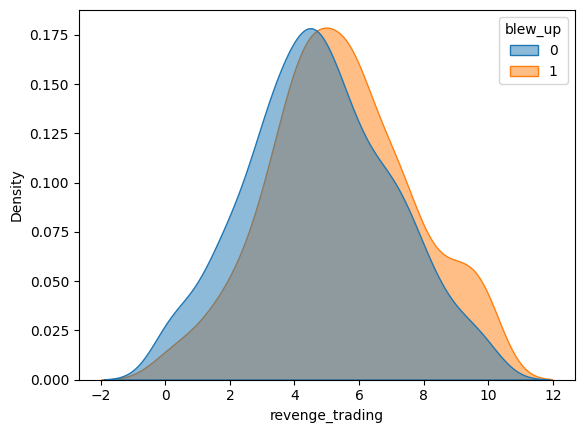

In [7]:
sns.kdeplot(data=df, x='revenge_trading', hue='blew_up', fill=True, common_norm=False, alpha=0.5)
plt.show()

Observation: The scatterplot did not give us much information, we looked at a density plot to see if traders actually revenge trade. The plot shows that most, whether or not their account blew up, return a 4-6 on revenge trading, meaning it is not a consistent habit amongst the dataset. 

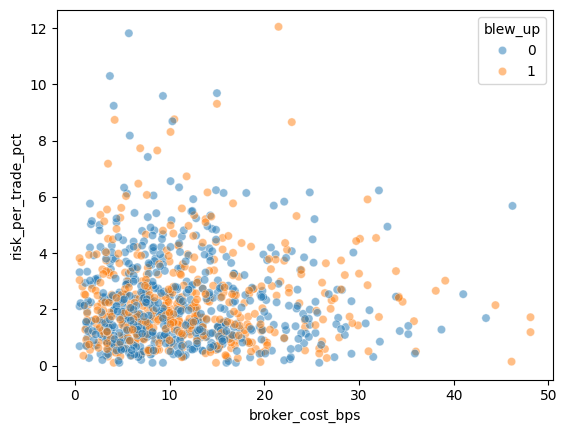

In [8]:
#scatterplot looking at broker cost bps and risk per trade pct (does higher broker cost lead to higher risk per trade?)
sns.scatterplot(data=df, x='broker_cost_bps', y='risk_per_trade_pct', alpha=0.5, hue='blew_up')
plt.show()

Observation: Most data points are clustered between 0-20 basis points and 0-5 for risk. There does not seem to be a correlation between broker cost and the risk per trade.

### Train/Test Split

Note: We split the data 80/20 into training and testing sets, keeping the same blowup ratio in both. To tune the models, we use 5 fold cross-validation on the training set only, so the test set stays untouched until the very end.

In [9]:
#Splitting data into features and target, then into train/test sets
X = df.drop(columns=['blew_up', 'net_return_pct', 'profitable', 'trader_id'])
y = df['blew_up']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_seed, stratify=y)
print('Train size =', X_train.shape[0])
print('Test size =', X_test.shape[0])
print('Blowup rate: train =', round(y_train.mean(), 3), '| test =', round(y_test.mean(), 3))

Train size = 800
Test size = 200
Blowup rate: train = 0.448 | test = 0.45


### Encoding and Rescaling Features

In [10]:
# Creating dummy variables for categorical data
X_train = pd.get_dummies(X_train, columns=['instrument', 'market_regime'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['instrument', 'market_regime'], drop_first=True)
#Making sure test set has the same columns as train set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
#Scaling numeric features, fitting only on the training data
numeric_cols = ['age', 'prior_experience_years', 'starting_capital', 'account_age_months',
                'broker_cost_bps', 'risk_per_trade_pct', 'avg_leverage', 'trades_per_month',
                'avg_win_hold_days', 'avg_loss_hold_days', 'diversification', 'revenge_trading',
                'overconfidence', 'follows_plan', 'chases_volatility', 'position_sizing_discipline']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train.head()

,age,prior_experience_years,starting_capital,account_age_months,broker_cost_bps,risk_per_trade_pct,avg_leverage,trades_per_month,uses_stop_loss,avg_win_hold_days,...,follows_plan,chases_volatility,position_sizing_discipline,instrument_etf,instrument_forex,instrument_futures,instrument_options,instrument_stocks,market_regime_bull,market_regime_choppy
27377,-0.791247,-0.690599,-0.454582,-0.791364,-0.079998,0.572982,-0.191596,0.859911,1,0.680875,...,-0.454484,1.137305,-0.053964,False,False,False,False,False,True,False
13519,-0.070293,-0.333700,-0.240306,0.439433,-1.320033,-0.606179,-0.367696,0.010983,1,-0.830746,...,-0.232514,-0.212888,-0.525784,False,True,False,False,False,False,True
47380,0.135694,-1.047498,-0.245251,-1.099063,-0.824019,1.278108,-0.191596,-0.583267,1,-0.167108,...,1.854005,-1.050939,1.219949,True,False,False,False,False,False,False
32755,-0.997233,-0.435672,-0.708417,-1.175988,-0.836419,-0.985407,3.013413,-1.347302,1,-0.462058,...,-1.564334,0.345812,-1.516606,False,True,False,False,False,False,True
6682,0.341681,5.682594,0.424775,0.362508,-1.047225,1.023315,-0.543795,-0.328588,0,0.459662,...,-0.365696,0.206137,-0.148328,False,False,False,False,True,True,False


### Logistic Regression

Note: C controls how much regularization gets applied, the smaller it is, the stronger the regularization. We test a range of values using grid search with 5 fold cross-validation on the training set to find the one that works best.

In [11]:
#Parameters used for gridsearch
parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
#Grid search for best C and best CV ROC-AUC
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=random_seed), parameters, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)
best_C = grid_search.best_params_['C']
print('Best C:', best_C)
print('Best CV ROC-AUC:', round(grid_search.best_score_, 4))
logreg = LogisticRegression(C=best_C, max_iter=1000, random_state=random_seed) 
logreg.fit(X_train, y_train);

Best C: 1
Best CV ROC-AUC: 0.685


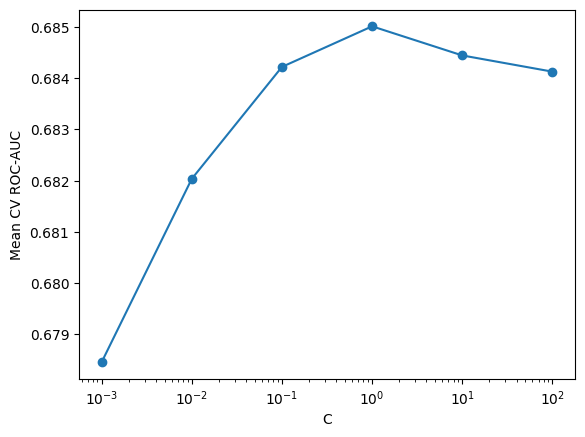

In [12]:
#Using best C to fit the model
mean_scores = grid_search.cv_results_['mean_test_score']
plt.plot(parameters['C'], mean_scores, marker='o')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV ROC-AUC')
plt.show()

Observation: The curve is pretty flat across C values. CV ROC-AUC barely moves between 0.679 and 0.685, meaning the model is not super sensitive to the regularization strength here, and C is equal to 1.

Train Accuracy: 0.67
Test Accuracy: 0.695
Test Sensitivity (TPR): 0.633
Test Specificity (TNR): 0.745


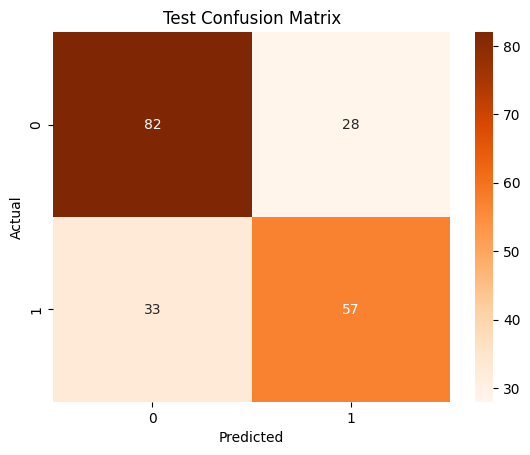

In [13]:
#Checking accuracy scores
logreg_train_pred = logreg.predict(X_train)
logreg_test_pred = logreg.predict(X_test)
print('Train Accuracy:', round(accuracy_score(y_train, logreg_train_pred), 3))
print('Test Accuracy:', round(accuracy_score(y_test, logreg_test_pred), 3))
#Calculation for TPR and TNR
conf_M_logreg = pd.crosstab(y_test, logreg_test_pred)
TP = conf_M_logreg.iloc[1, 1]
FN = conf_M_logreg.iloc[1, 0]
FP = conf_M_logreg.iloc[0, 1]
TN = conf_M_logreg.iloc[0, 0]
print('Test Sensitivity (TPR):', round(TP / (TP + FN), 3))
print('Test Specificity (TNR):', round(TN / (TN + FP), 3))
#Confusion matrix for logistic regression
sns.heatmap(conf_M_logreg, annot=True, fmt='d', cmap='Oranges')
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Observation: Train accuracy and test accuracy are actually close, although test is a little higher than train. Sensitivity is lower than specificity, meaning the model still misses about a third of traders who actually blow up.

### Random Forest

Note: We tune n_estimators (number of trees) and max_depth the same way, with grid search and 5 fold cross-validation.

In [14]:
#Parameters used for gridsearch
parameters = {'n_estimators': [100, 200, 400], 'max_depth': [3, 5, 10, None]}
#Grid search for best pramaters and best CV ROC-AUC
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_seed), parameters, cv=5, scoring='roc_auc')
grid_search_rf.fit(X_train, y_train)
best_params = grid_search_rf.best_params_
print('Best params:', best_params)
print('Best CV ROC-AUC:', round(grid_search_rf.best_score_, 4))
rf = RandomForestClassifier(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], random_state=random_seed)
rf.fit(X_train, y_train);

Best params: {'max_depth': 5, 'n_estimators': 400}
Best CV ROC-AUC: 0.6876


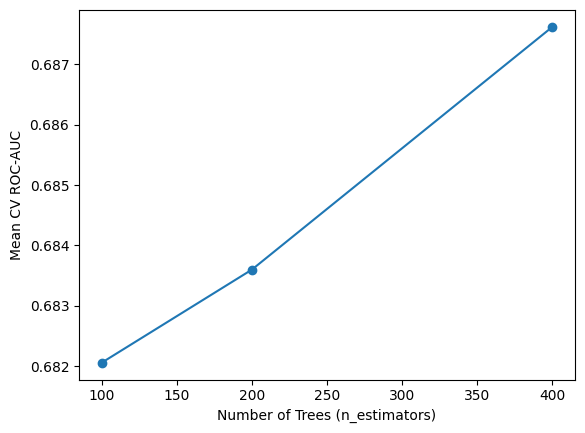

In [15]:
#Graph to find the relationship between the number of trees and the mean CV of ROC-AUC
results = pd.DataFrame(grid_search_rf.cv_results_)
results_best_depth = results[results['param_max_depth'] == best_params['max_depth']]
plt.plot(results_best_depth['param_n_estimators'], results_best_depth['mean_test_score'], marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean CV ROC-AUC')
plt.show()

Note: If we had more time, we think it would be worth testing 600 to 800 to see if it flattens.

Train Accuracy: 0.836
Test Accuracy: 0.655
Test Sensitivity (TPR): 0.456
Test Specificity (TNR): 0.818


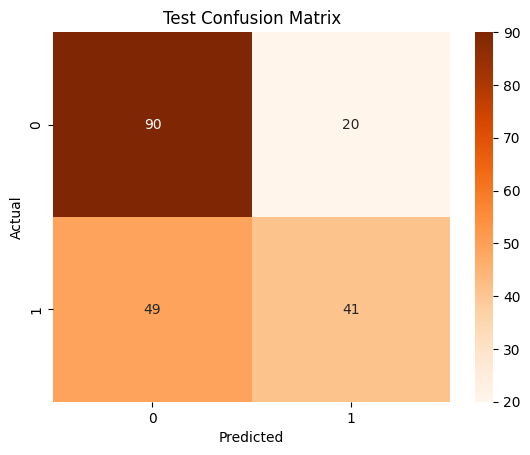

In [16]:
#Confusion matrix for Random Forest
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)
print('Train Accuracy:', round(accuracy_score(y_train, rf_train_pred), 3))
print('Test Accuracy:', round(accuracy_score(y_test, rf_test_pred), 3))
conf_M_rf = pd.crosstab(y_test, rf_test_pred)
TP = conf_M_rf.iloc[1, 1]
FN = conf_M_rf.iloc[1, 0]
FP = conf_M_rf.iloc[0, 1]
TN = conf_M_rf.iloc[0, 0]
print('Test Sensitivity (TPR):', round(TP / (TP + FN), 3))
print('Test Specificity (TNR):', round(TN / (TN + FP), 3))
sns.heatmap(conf_M_rf, annot=True, fmt='d', cmap='Oranges')
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

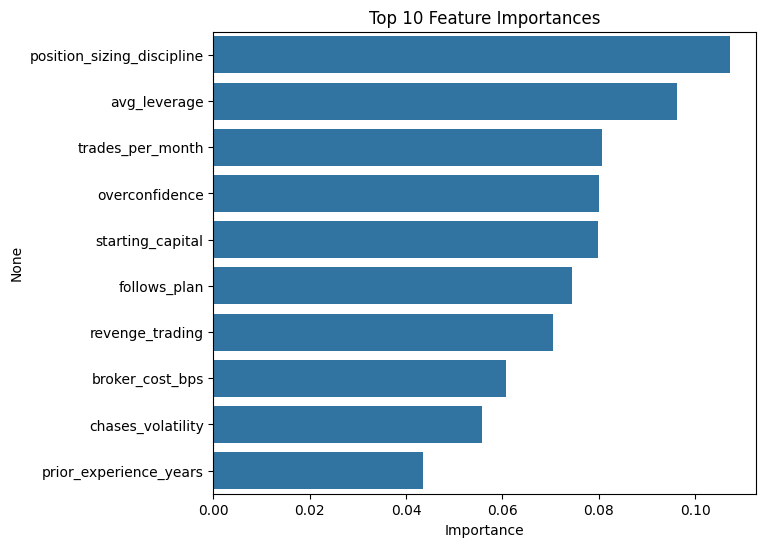

In [17]:
#Which features mattered most to the random forest?
importance = pd.DataFrame(rf.feature_importances_, index=X_train.columns, columns=['Importance'])
importance = importance.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(7, 6))
sns.barplot(x='Importance', y=importance.index, data=importance)
plt.title('Top 10 Feature Importances')
plt.show()

Observation: position_sizing_discipline and avg_leverage come out on top, which lines up with the dataset description's own claim that leverage is a "blow-up engine" showing that discipline matters. starting_capital is a circumstance feature which shows up in the top 5 too, so it's not purely behavioral, even if behavior dominates.

### Logistic Regression vs Random Forest

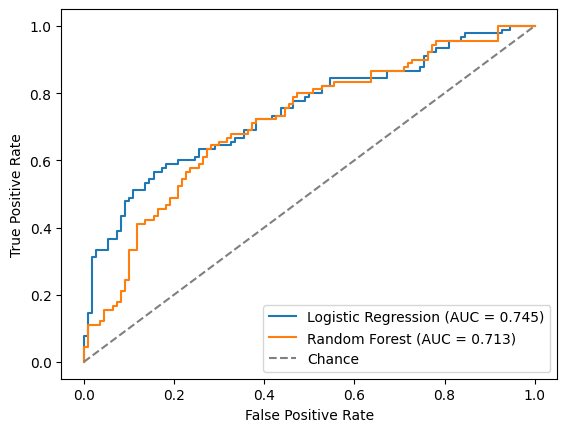

In [18]:
# Comparing the results from both models
logreg_probs = logreg.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, logreg_probs):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Conclusion

In the end, our two models ended up pretty close, but logistic regression came out ahead, it scored a 0.745 ROC-AUC compared to random forest's 0.713. What stood out to us was that random forest actually did a great job training on the data but dropped off a lot on the test set, so it was overfitting. Logistic regression stayed pretty consistent between the two, which tells me it generalizes better even though it's the simpler model. 

Position sizing discipline and leverage turned out to be the biggest predictors of blowing up an account, which honestly makes sense to us, if you're oversized on a position or using too much leverage, one bad trade can tank the whole account fast. It was a little surprising that starting capital mattered too, since that's not really something a trader controls. 

If we did this again, we'd want to try to separate the behavioral features from the circumstantial ones to see how much of blowing up is actually on the trader versus just bad luck. We'd push the random forest to more trees since it still looked like it was improving at 400 and hadn't flattened out yet. 

Overall, this was a good project to work through. It made us think more about what "better" even means for a model, and it taught us how you can gain information from a model on how to handle situations and progress positively for a trader in this case.